# **GPA Change Analysis**

write the outlook of the project.

# Introduction:
These days AI is growing fast and we can say it's a most used tool on our daily tasks. Huge improvements of the field and the genesis of chatbots caused by the improvements and fundings we can see some useful AI tools like ChatGPT, Claude, etc. These tools changed our lifes and make task and learning different. It was my own problem with the AI that what are the conciquencies of using AI? Does AI have negative effects on our long-term memory and our IQ level? Not using AI will results in low progression among high level and efficient people that we wanna compete and I'm not sure using AI a lot results in good things for our brain so I try to answer some of the questions using this analysis and I hope the results and conclusions make us to decide better on using AI in which way and for how many hours.

This dataset has some useful features and lots of samples that helps us on our way to make data-driven decisions abour AI usage in our lifes.


dataset source: https://www.kaggle.com/datasets/laveshjadon/ai-impact-on-students

# Problem Definition:
**How does AI usage correlated with academic improvement or declined?**

This is the main question we're trying to find solution for and we're going to define a regression task for it. We're going to train and built a regression model on this dataset to predict the GPA change of the students based-on the features related to their academic profile, AI behaviour, study habits, institutional policies, and well-being.

📁 **AI_Student_Impact_Dataset**:

🪪 `Identifier:` Student_ID

🎓 `Academic Profile:` Major_Category, Year_of_Study, Pre/Post GPA

🤖 `AI Behaviour:` Weekly_GenAI_Hours, Primary_Use_Case, Prompt_Engineering_Skill, Tool_Diversity, Paid_Subscription

📚 `Study Habits:` Traditional_Study_Hours, Perceived_AI_Dependency

🏛️ `Institutional:` Institutional_Policy

🧠 `Well-being:` Anxiety_Level, Skill_Retention_Score, Burnout_Risk_Level

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import category_encoders as ce

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, learning_curve, cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error
from sklearn.metrics import r2_score, make_scorer

import preprocessing as pr

print("Importations Successful.")

Importations Successful.


In [2]:
# versions of the used third-party packages
from sklearn import __version__ as sklearn_version
from numpy import __version__ as np_version
from pandas import __version__ as pd_version
from seaborn import __version__ as sns_version
from matplotlib import __version__ as plt_version

print(f"Scikit-learn's Version: {sklearn_version}")
print(f"NumPy's Version: {np_version}")
print(f"Pandas's Version: {pd_version}")
print(f"Seaborn's Version: {sns_version}")
print(f"Matploblib's Version: {plt_version}")

Scikit-learn's Version: 1.9.0
NumPy's Version: 2.4.2
Pandas's Version: 3.0.0
Seaborn's Version: 0.13.2
Matploblib's Version: 3.10.8


In [3]:
sns.set_theme(
    context="notebook",
    style="whitegrid",
    font_scale=1.1
)

## 1. Data Structure and Types Examinations

In [4]:
df = pd.read_csv("/mnt/d/Pytopia/Machine Learning/Applied-ML-Lab/core_ml/regression/impact_of_ai_on_students/data/ai_student_impact_dataset (1).csv")
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [5]:
df.shape

(50000, 16)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           50000 non-null

In [7]:
pr.describe(df)

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.250005e+05,3.146102,8.427752,2.800260,11.209271,3.505360,4.270760,3.349299,75.798125
median,1.250005e+05,3.210000,5.800000,3.000000,11.180000,3.000000,4.000000,3.421000,76.000000
std,1.443390e+04,0.478854,8.269490,1.188020,5.156426,1.820812,2.144066,0.495673,13.281626
variance,2.083375e+08,0.229301,68.384460,1.411392,26.588730,3.315358,4.597021,0.245691,176.401597
min,1.000010e+05,1.183000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,1.125008e+05,2.834000,2.390000,2.000000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,1.250005e+05,3.210000,5.800000,3.000000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,1.375002e+05,3.521000,11.720000,4.000000,14.710000,5.000000,6.000000,3.749000,85.190000
max,1.500000e+05,3.998000,40.000000,5.000000,35.860000,10.000000,10.000000,4.000000,100.000000


In [8]:
df['Student_ID'].nunique() == 50_000

True

In [9]:
# fixing datatypes for categorical variables
df['Major_Category'] = df['Major_Category'].str.lower().astype("category")
df['Year_of_Study'] = df['Year_of_Study'].str.lower().astype("category")
df['Primary_Use_Case'] = df['Primary_Use_Case'].str.lower().astype("category")
df['Prompt_Engineering_Skill'] = df['Prompt_Engineering_Skill'].str.lower().astype("category")
df['Institutional_Policy'] = df['Institutional_Policy'].str.lower().astype("category")
df['Burnout_Risk_Level'] = df['Burnout_Risk_Level'].str.lower().astype("category")

In [10]:
print("percentage of each category in `Major_Category`:")
df['Major_Category'].value_counts() / df.shape[0] * 100

percentage of each category in `Major_Category`:


Major_Category
stem          30.118
business      25.076
humanities    19.988
medical       12.952
arts          11.866
Name: count, dtype: float64

In [11]:
pr.category_percentage(df['Major_Category'])

,Major_Category,percent
0,stem,% 30.12
1,business,% 25.08
2,humanities,% 19.99
3,medical,% 12.95
4,arts,% 11.87


In [12]:
pr.category_percentage(df['Year_of_Study'])

,Year_of_Study,percent
0,junior,% 22.09
1,freshman,% 22.06
2,senior,% 21.27
3,sophomore,% 19.72
4,graduate,% 14.86


/tmp/ipykernel_12450/928278326.py:34: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


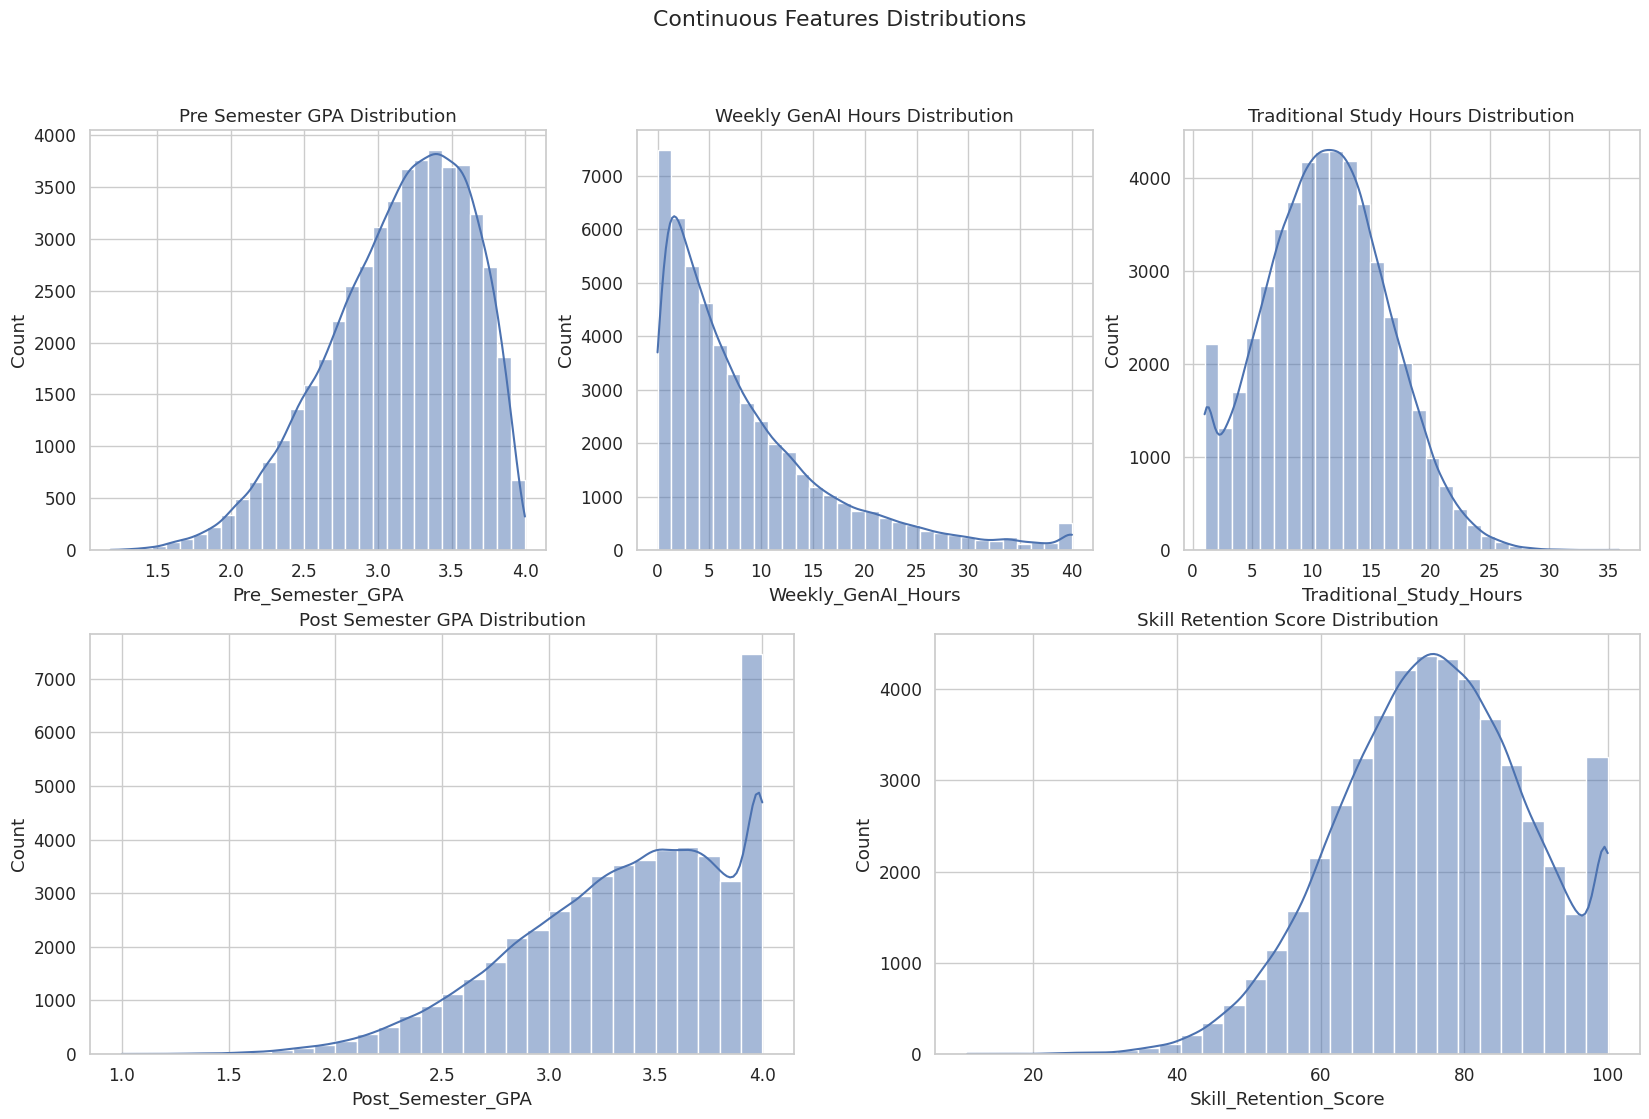

In [13]:
fig = plt.figure(figsize=(20, 12))
plt.suptitle("Continuous Features Distributions")

ax1 = plt.subplot(231)
sns.histplot(data=df, x="Pre_Semester_GPA", kde=True, bins=30, ax=ax1)
ax1.set(
    title="Pre Semester GPA Distribution"
)

ax2 = plt.subplot(232)
sns.histplot(data=df, x="Weekly_GenAI_Hours", kde=True, bins=30, ax=ax2)
ax2.set(
    title="Weekly GenAI Hours Distribution"
)

ax3 = plt.subplot(233)
sns.histplot(data=df, x="Traditional_Study_Hours", kde=True, bins=30, ax=ax3)
ax3.set(
    title="Traditional Study Hours Distribution"
)

ax4 = plt.subplot(223)
sns.histplot(data=df, x="Post_Semester_GPA", kde=True, bins=30, ax=ax4)
ax4.set(
    title="Post Semester GPA Distribution"
)

ax5 = plt.subplot(224)
sns.histplot(data=df, x="Skill_Retention_Score", kde=True, bins=30, ax=ax5)
ax5.set(
    title="Skill Retention Score Distribution"
)

plt.tight_layout()

by looking at the distribution of the weekly GenAI hours we can say maybe a log transformation on this feature makes it more like normal distribution and may results in a better feature.

In [14]:
pr.category_percentage(df['Primary_Use_Case'])

,Primary_Use_Case,percent
0,debugging/troubleshooting,% 24.59
1,copywriting/drafting,% 24.02
2,ideation,% 21.44
3,summarizing_reading,% 17.27
4,direct_answer_generation,% 12.68


In [15]:
pr.category_percentage(df['Prompt_Engineering_Skill'])

,Prompt_Engineering_Skill,percent
0,beginner,% 36.99
1,intermediate,% 35.39
2,advanced,% 27.62


In [16]:
pr.category_percentage(df['Tool_Diversity'])

,Tool_Diversity,percent
0,3,% 33.85
1,2,% 23.66
2,1,% 16.28
3,4,% 16.16
4,5,% 10.04


In [17]:
pr.category_percentage(df["Paid_Subscription"])

,Paid_Subscription,percent
0,False,% 57.69
1,True,% 42.31


We can see most of the students do not pay for the AI subscription and it can have this meaning that the number of students who are the professional user of the AI are less than the students who use AI a little not for high level tasks also cause doing high-level tasks and using AI regularly needs many tokens usage so they must by the subscription to do this.

In [18]:
pr.category_percentage(df['Perceived_AI_Dependency'])

,Perceived_AI_Dependency,percent
0,3,% 20.96
1,4,% 19.87
2,2,% 17.75
3,1,% 14.61
4,5,% 13.49
5,6,% 7.04
6,7,% 3.44
7,8,% 1.71
8,9,% 0.76
9,10,% 0.38


we can see that not many students are much dependent on the AI and can handle their tasks in traditional ways.

In [19]:
students_with_high_ai_dependency_percent = pr.category_percentage(
    df['Perceived_AI_Dependency']).iloc[5:, 1].str.replace("%", "").astype(float).sum()

print(f"Percentage of students with High AI dependency: %{students_with_high_ai_dependency_percent: .2f}")

Percentage of students with High AI dependency: % 13.33


In [20]:
pr.category_percentage(df['Institutional_Policy'])

,Institutional_Policy,percent
0,allowed_with_citation,% 50.45
1,actively_encouraged,% 29.98
2,strict_ban,% 19.58


In [21]:
pr.category_percentage(df['Anxiety_Level_During_Exams'])

,Anxiety_Level_During_Exams,percent
0,4,% 17.50
1,5,% 16.44
2,3,% 15.61
3,6,% 12.21
4,2,% 11.50
5,1,% 11.31
6,7,% 7.70
7,8,% 4.18
8,9,% 2.30
9,10,% 1.24


In [22]:
pr.category_percentage(df['Burnout_Risk_Level'])

,Burnout_Risk_Level,percent
0,medium,% 42.29
1,low,% 32.74
2,high,% 24.97


## 2. Handling Missing Values & De-Duplication Task:

This dataset is a ready-to-use dataset and there is no missing values or duplicates in it by the publisher's note. just to make sure:

In [23]:
# number of missing values
df.isnull().sum().sum()

np.int64(0)

In [24]:
# number of the duplicated samples
df.duplicated().sum()

np.int64(0)

## 3. Handling Data Irregularities: (Hold for now)

In [25]:
numeric_features = []
for column in df.columns:
    if df[column].dtype not in ["category", "bool"]:
        numeric_features.append(column)

numeric_features

['Student_ID',
 'Pre_Semester_GPA',
 'Weekly_GenAI_Hours',
 'Tool_Diversity',
 'Traditional_Study_Hours',
 'Perceived_AI_Dependency',
 'Anxiety_Level_During_Exams',
 'Post_Semester_GPA',
 'Skill_Retention_Score']

In [26]:
potential_outliers = {}
for i in range(len(numeric_features)):
	potential_outliers[numeric_features[i]] = pr.detect_potential_outliers(df, numeric_features[i])

potential_outliers

{'Student_ID': RangeIndex(start=0, stop=0, step=1),
 'Pre_Semester_GPA': Index([   31,   198,   443,   671,   853,  1212,  1738,  1835,  2401,  2561,
        ...
        47997, 48302, 48331, 48394, 48443, 48773, 48943, 49426, 49580, 49662],
       dtype='int64', length=197),
 'Weekly_GenAI_Hours': Index([   89,   124,   148,   149,   184,   304,   319,   333,   363,   380,
        ...
        49669, 49693, 49777, 49785, 49821, 49828, 49850, 49877, 49908, 49937],
       dtype='int64', length=1144),
 'Tool_Diversity': RangeIndex(start=0, stop=0, step=1),
 'Traditional_Study_Hours': Index([ 1056,  1461,  1854,  2080,  4444,  4465,  4592,  4709,  5400,  6120,
         7668,  8047, 10074, 10520, 12235, 12298, 12748, 13489, 14014, 15603,
        16048, 16272, 17095, 18166, 18446, 19500, 20110, 20267, 20932, 22719,
        22862, 24408, 25568, 25580, 26271, 26394, 26872, 26891, 27307, 28615,
        28796, 30291, 30377, 30426, 30428, 30522, 31162, 31477, 31769, 32804,
        33086, 33101, 33

<Axes: xlabel='Pre_Semester_GPA', ylabel='Count'>

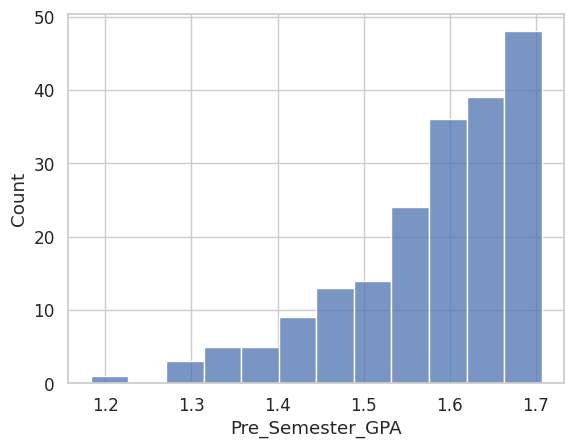

In [27]:
sns.histplot(df.loc[potential_outliers['Pre_Semester_GPA'], "Pre_Semester_GPA"])

## 4. Feature Engineering:

### Feaure Creation and Transformation:

Text(0.5, 1.0, 'GPA Difference Distribution')

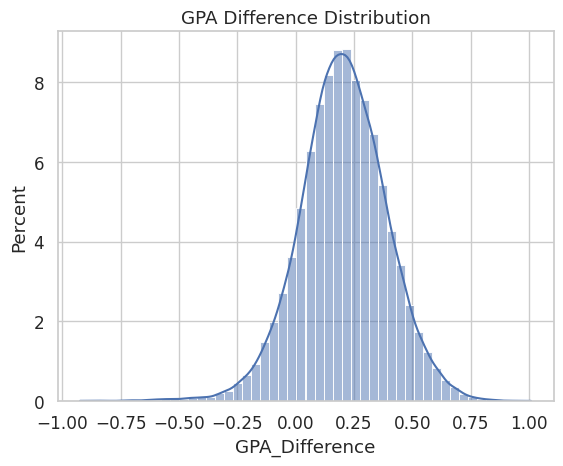

In [28]:
df['GPA_Difference'] = df['Post_Semester_GPA'] - df['Pre_Semester_GPA']

sns.histplot(data=df, x="GPA_Difference", kde=True, bins=50, stat="percent")
plt.title("GPA Difference Distribution")

In [29]:
df['GPA_Difference'].describe()

count    50000.000000
mean         0.203197
std          0.187192
min         -0.924000
25%          0.087000
50%          0.204000
75%          0.325000
max          1.008000
Name: GPA_Difference, dtype: float64

By seeing that our target variable has a normal distribution we've passed one of the assumptions for linear regression model and maybe modeling this dataset for GPA difference prediction task using linear regression results in good predictions.

# 5. Explorations:

In [30]:
df.groupby("Major_Category")['Weekly_GenAI_Hours'].mean()

Major_Category
arts           7.271702
business       8.275898
humanities     6.770144
medical        7.546728
stem          10.488609
Name: Weekly_GenAI_Hours, dtype: float64

In [31]:
print("Weekly GenAI hours by major category:")
df.pivot_table(
    values="Weekly_GenAI_Hours",
    index="Major_Category",
    columns="Year_of_Study",
).mean(axis=1)

Weekly GenAI hours by major category:


Major_Category
arts           7.277241
business       8.280224
humanities     6.779554
medical        7.558905
stem          10.467515
dtype: float64

STEM major category students average usage of the AI is much more than other major categories.

In [32]:
year_of_study_sorted = ["freshman", "sophomore", "junior", "senior", "graduate"]
df.pivot_table(
    values="Traditional_Study_Hours",
    index="Major_Category",
    columns="Year_of_Study",
).loc[:, year_of_study_sorted].mean(axis=1)

Major_Category
arts          11.369427
business      11.203602
humanities    11.320793
medical       11.369779
stem          11.005075
dtype: float64

students have from different majors almost have the same study hours.

In [33]:
df.pivot_table(
    values="Skill_Retention_Score",
    index="Major_Category",
    columns="Year_of_Study",
).mean(axis=1)

Major_Category
arts          75.756203
business      75.395248
humanities    75.348286
medical       75.605528
stem          76.876486
dtype: float64

We can see that the higher AI hours usage does not result in lower skill retention for STEM major category students in general.

In [34]:
print("Primary usage of each major category:")
df.pivot_table(
    values="Weekly_GenAI_Hours",
    index="Major_Category",
    columns="Primary_Use_Case",
).style.highlight_max(axis=1, props="background-color: green; color: black")

Primary usage of each major category:


Primary_Use_Case,copywriting/drafting,debugging/troubleshooting,direct_answer_generation,ideation,summarizing_reading
Major_Category,,,,,
arts,7.079039,7.600061,7.286136,7.669858,7.133167
business,8.086853,8.455982,8.397550,8.325226,7.977930
humanities,6.876253,6.375336,6.599464,6.742134,6.879968
medical,7.184280,7.591809,7.315104,7.673786,7.657968
stem,10.352187,10.445044,10.689452,10.479799,10.615806


In [35]:
df.pivot_table(
    values="Traditional_Study_Hours",
    index="Major_Category",
    columns="Primary_Use_Case",
)

Primary_Use_Case,copywriting/drafting,debugging/troubleshooting,direct_answer_generation,ideation,summarizing_reading
Major_Category,,,,,
arts,11.480311,11.176175,11.373050,10.875905,11.586916
business,11.115821,11.192232,11.207738,11.212835,11.274560
humanities,11.460557,11.175448,11.375610,11.154005,11.121037
medical,11.185907,11.536155,11.313291,11.301839,11.394329
stem,10.884931,11.050112,11.014767,10.947872,10.975083


In [36]:
df.pivot_table(
    values="Post_Semester_GPA",
    index="Major_Category",
    columns="Primary_Use_Case",
)

Primary_Use_Case,copywriting/drafting,debugging/troubleshooting,direct_answer_generation,ideation,summarizing_reading
Major_Category,,,,,
arts,3.335106,3.412374,3.280752,3.375924,3.332401
business,3.325177,3.394387,3.263723,3.342111,3.339186
humanities,3.340246,3.332432,3.356198,3.351537,3.366199
medical,3.346966,3.395354,3.315878,3.360430,3.351273
stem,3.325311,3.403913,3.279012,3.320544,3.354301


We can see a pattern that STEM major category students that their primary use case of using AI are copywriting/drafting or ideation, spent less time on studying in traditional ways but the average GPA of them is very similar to others but students in this major category whos primary use case was getting direct answers from the AI do worse than others in this major category by GPA score.

STEM major category students are a little AI dependent in average.

In [37]:
df.pivot_table(
    values="Skill_Retention_Score",
    index="Major_Category",
    columns="Primary_Use_Case",
).style.highlight_min(axis=1, props="background-color: red; color: white").highlight_max(
        axis=1, props="background-color: green; color: black"
	)

Primary_Use_Case,copywriting/drafting,debugging/troubleshooting,direct_answer_generation,ideation,summarizing_reading
Major_Category,,,,,
arts,75.580484,77.951072,74.633925,74.846402,75.497983
business,74.546163,76.938372,73.625743,75.500935,75.011123
humanities,75.110279,77.196420,74.148955,75.647890,74.657584
medical,74.707735,77.231092,73.925901,75.861707,75.523845
stem,75.912964,78.543921,73.037907,75.655056,75.172458


> **Pattern:** An important pattern identified that in all majors we can see that using AI to generate and give direct answers results in lower skill retention score that means giving direct answers from AI could damage your long-term skill retention. Another pattern that is visible is that using AI for debugging/troubleshooting has the least effect on the skill retention score and students whose primary use case from AI where debugging/troubleshooting did better in this part and maybe we can say using AI for debugging the things you already learned in traditional ways and to try solving problems more efficient results in better skill retention.

In [38]:
skill_retention_by_prompt_engineering_skill = df.groupby(
    by="Prompt_Engineering_Skill"
)['Skill_Retention_Score'].median().sort_values(ascending=False)

print("skill retention score by prompt engineering skill:")
skill_retention_by_prompt_engineering_skill

skill retention score by prompt engineering skill:


Prompt_Engineering_Skill
advanced        82.730
intermediate    76.055
beginner        71.320
Name: Skill_Retention_Score, dtype: float64

[Text(0.5, 1.0, 'Skill Retention Score by Promp Engineering Skill'),
 Text(0.5, 0, 'Skill Retention Score'),
 Text(0, 0.5, 'Prompt Engineering Skill')]

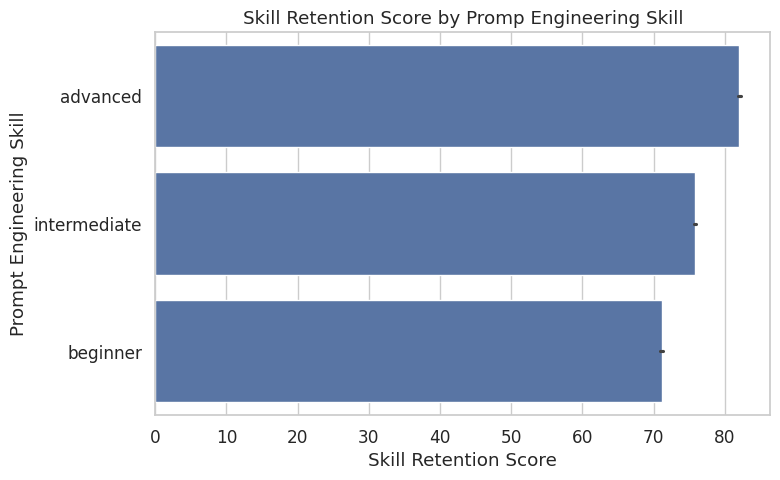

In [39]:
fig, ax = plt.subplots(figsize=(8, 5), tight_layout=True)

sns.barplot(
    data=df,
    y="Prompt_Engineering_Skill",
    x="Skill_Retention_Score",
    order=["advanced", "intermediate", "beginner"],
    errorbar=("ci", 95),
    ax=ax
)
ax.set(
    title="Skill Retention Score by Promp Engineering Skill",
    xlabel="Skill Retention Score",
    ylabel="Prompt Engineering Skill",
    
)

There is another valuable pattern here and we can see that there is a significant difference in the skill retention score for students based-on their prompt engineering skill. Students with higher promp engineering skills did signifactly better in skiil retention score and we can say by improving the prompt engineering skills students can improve their skill retention and use AI more wisely.

Text(0.5, 1.0, 'GPA Difference Vs. Weekly GenAI Hours for Direct Answer Generation')

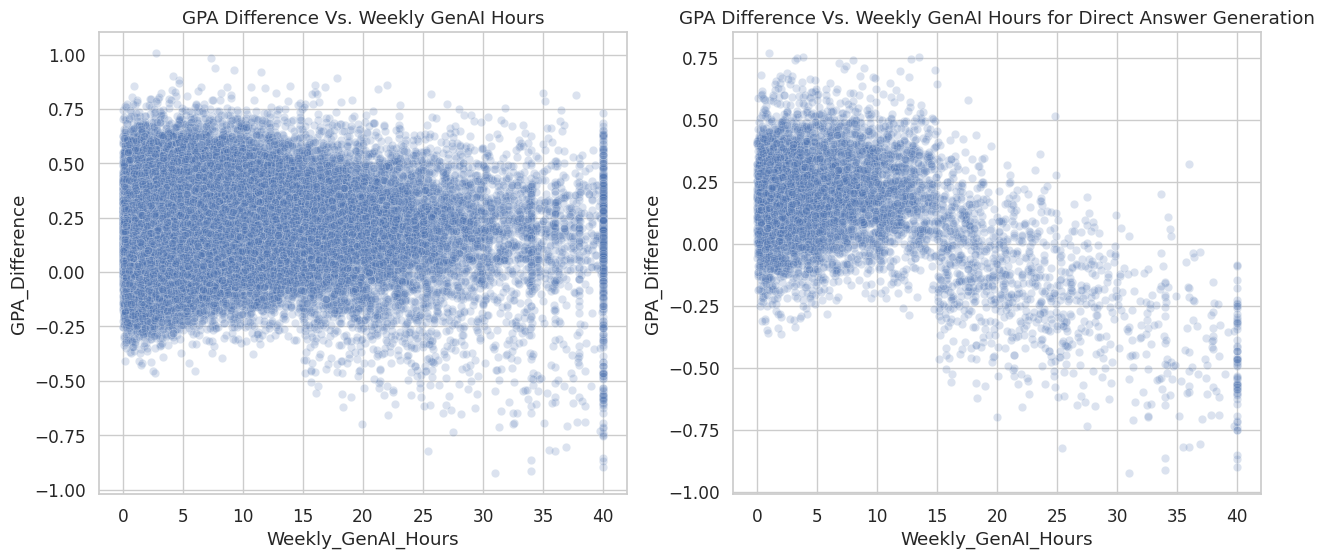

In [40]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(
    data=df,
    x="Weekly_GenAI_Hours",
    y="GPA_Difference",
    alpha=0.2,
    ax=ax1
)
ax1.set_title("GPA Difference Vs. Weekly GenAI Hours")

sns.scatterplot(
    data=df,
    x="Weekly_GenAI_Hours",
    y=df['GPA_Difference'][df['Primary_Use_Case'] == "direct_answer_generation"],
    alpha=0.2,
    ax=ax2
)
ax2.set_title("GPA Difference Vs. Weekly GenAI Hours for Direct Answer Generation")

Using this plot we can see GPA difference when the students primary use case of using AI was direct answer generation results in a significantly drop in their educational performance.

we can say we have heteroscedasticity here.

### Encoding Categorical Variables:

In [41]:
df['Paid_Subscription'] = df['Paid_Subscription'].astype("category").cat.codes
df.head(10)

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level,GPA_Difference
0,100001,humanities,senior,2.418,23.31,copywriting/drafting,beginner,1,1,8.13,5,allowed_with_citation,6,2.393,86.44,high,-0.025
1,100002,medical,junior,3.821,1.12,ideation,advanced,5,0,16.65,3,allowed_with_citation,9,3.696,69.39,low,-0.125
2,100003,business,freshman,3.398,21.26,summarizing_reading,beginner,2,0,10.35,5,strict_ban,9,3.499,73.93,medium,0.101
3,100004,business,senior,3.789,1.82,copywriting/drafting,intermediate,4,0,15.23,2,allowed_with_citation,2,4.000,63.58,medium,0.211
4,100005,stem,sophomore,3.635,9.29,debugging/troubleshooting,advanced,4,0,12.55,4,allowed_with_citation,4,3.798,100.00,medium,0.163
5,100006,stem,junior,3.449,6.50,debugging/troubleshooting,beginner,1,0,14.19,4,allowed_with_citation,5,3.666,65.92,high,0.217
6,100007,stem,freshman,3.622,31.41,summarizing_reading,advanced,5,1,13.11,8,allowed_with_citation,7,4.000,67.97,medium,0.378
7,100008,arts,junior,2.746,5.33,copywriting/drafting,intermediate,3,0,18.45,2,actively_encouraged,1,2.965,85.09,medium,0.219
8,100009,business,sophomore,3.420,2.00,debugging/troubleshooting,beginner,2,1,2.87,1,strict_ban,5,3.396,55.71,medium,-0.024
9,100010,business,sophomore,3.046,19.99,debugging/troubleshooting,intermediate,2,1,12.49,3,strict_ban,8,2.978,87.18,high,-0.068


In [42]:
# creating the inputs 
feature_names = [feature for feature in df.columns if feature not in ["Student_ID", "GPA_Difference"]]

X = df[feature_names]
y = df['GPA_Difference']

# encoding
oh_encoding_cols = ["Major_Category", "Primary_Use_Case", "Institutional_Policy"]
ordinal_cols = ["Year_of_Study", "Prompt_Engineering_Skill", "Burnout_Risk_Level"]
mapping = [
    {
        "col": "Year_of_Study",
        "mapping": {
            "freshman": 0,
            "sophomore": 1,
            "junior": 2,
            "senior": 3,
            "graduate": 4
		}
	},
    {
        "col": "Prompt_Engineering_Skill",
        "mapping":{
            "beginner": 0,
            "intermediate": 1,
            "advanced": 2
		}
	},
    {
        "col": "Burnout_Risk_Level",
        "mapping": {
            "low": 0,
            "medium": 1,
            "high": 2
		}
	}
]

encoder = Pipeline(
    steps=[
        ("one_hot", ce.OneHotEncoder(cols=oh_encoding_cols, use_cat_names=True)),
        ("ordinal_1", ce.OrdinalEncoder(mapping=mapping, cols=ordinal_cols))
	]
)
features_encoded = pd.DataFrame(
    data=encoder.fit_transform(X),
    columns=encoder.get_feature_names_out()
)

# droping the non-informative column in the one-hot encoded features (one is non-informative in each)
non_informative_features = ["Major_Category_arts", "Primary_Use_Case_direct_answer_generation", "Institutional_Policy_actively_encouraged"]
informative_features = [feature for feature in features_encoded.columns if feature not in non_informative_features]
features_encoded = features_encoded[informative_features]

features_encoded

,Major_Category_humanities,Major_Category_medical,Major_Category_business,Major_Category_stem,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case_copywriting/drafting,Primary_Use_Case_ideation,Primary_Use_Case_summarizing_reading,...,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy_allowed_with_citation,Institutional_Policy_strict_ban,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,1,0,0,0,3,2.418,23.31,1,0,0,...,1,1,8.13,5,1,0,6,2.393,86.44,2
1,0,1,0,0,2,3.821,1.12,0,1,0,...,5,0,16.65,3,1,0,9,3.696,69.39,0
2,0,0,1,0,0,3.398,21.26,0,0,1,...,2,0,10.35,5,0,1,9,3.499,73.93,1
3,0,0,1,0,3,3.789,1.82,1,0,0,...,4,0,15.23,2,1,0,2,4.000,63.58,1
4,0,0,0,1,1,3.635,9.29,0,0,0,...,4,0,12.55,4,1,0,4,3.798,100.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,0,0,1,0,3,2.899,12.16,1,0,0,...,2,0,13.36,2,1,0,2,3.584,66.16,2
49996,0,0,0,1,3,2.870,2.51,1,0,0,...,1,0,4.67,3,0,0,3,3.096,81.62,1
49997,0,0,1,0,3,3.177,15.87,0,0,1,...,5,1,3.92,4,1,0,5,3.605,97.21,2
49998,0,0,1,0,2,3.398,19.91,0,0,0,...,5,0,7.10,5,1,0,3,3.527,84.12,1


Text(0.5, 1.0, 'Correlation Matrix of the Original Features')

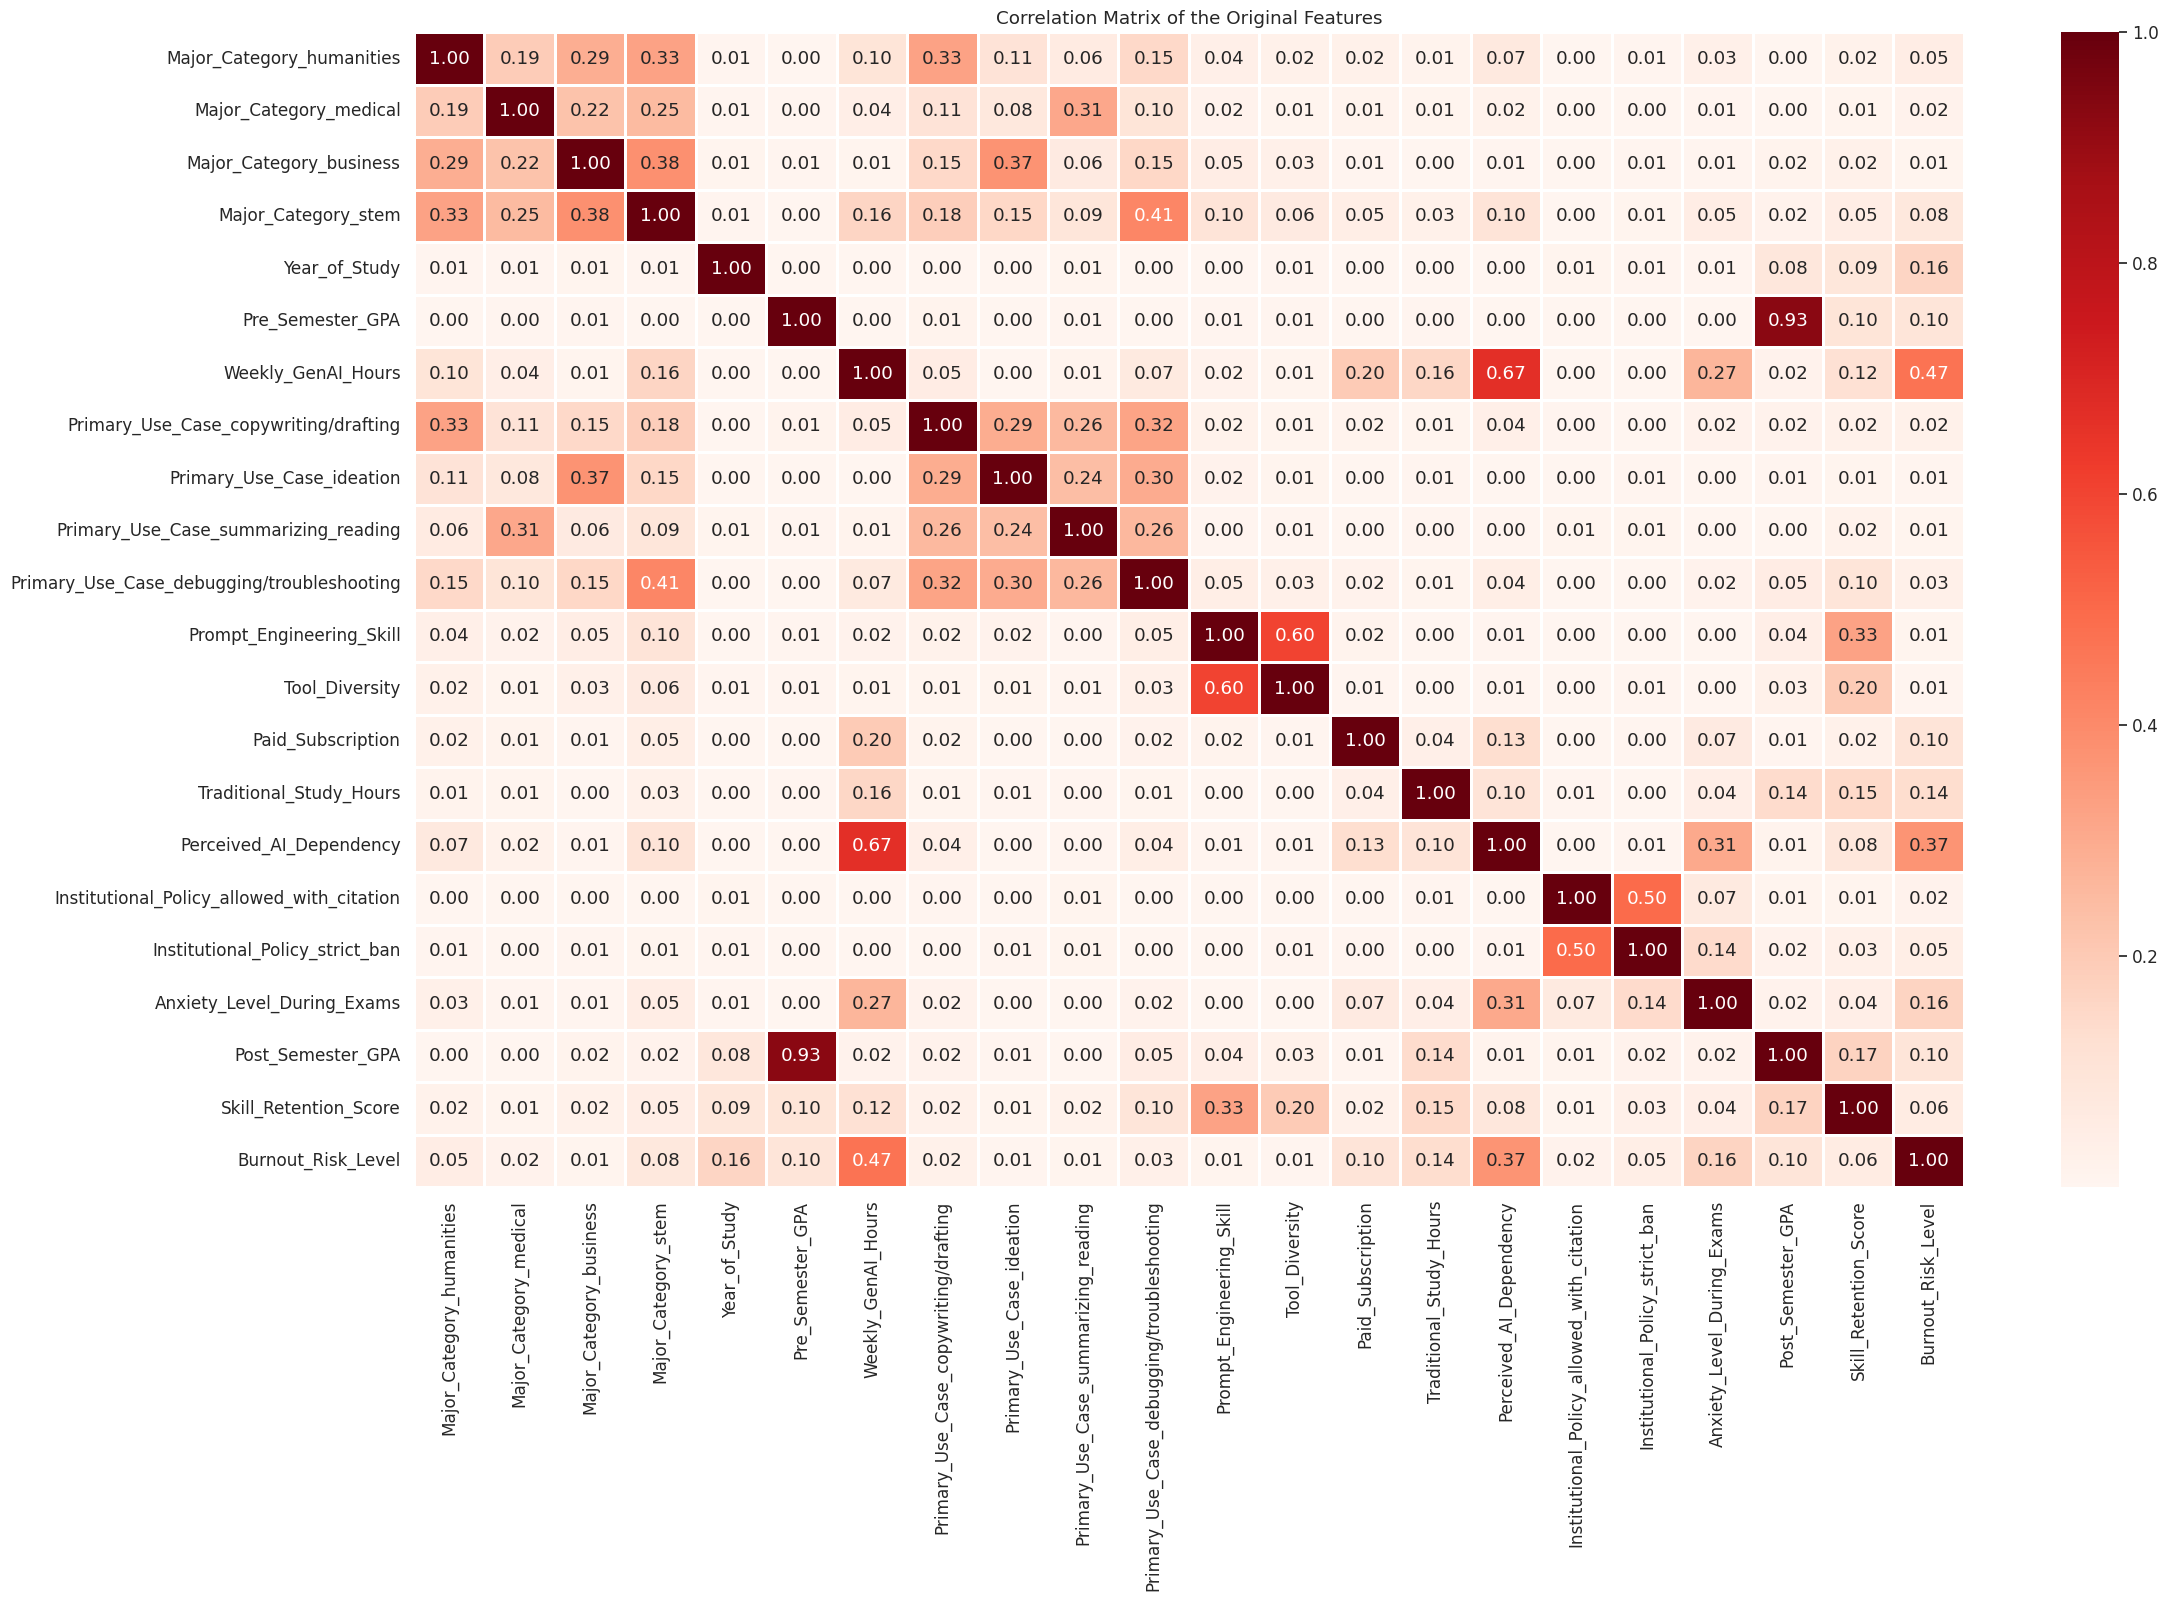

In [43]:
# correlation analysis
org_correlation_matrix = features_encoded.corr()
plt.figure(figsize=(25, 15))

sns.heatmap(
    data=abs(org_correlation_matrix),
    cmap="Reds",
    annot=True,
    linewidths=2,
    fmt=".2f"
)
plt.title("Correlation Matrix of the Original Features")

In [44]:
org_correlation_matrix.loc["Post_Semester_GPA", "Pre_Semester_GPA"]

np.float64(0.9267808745085381)

In [45]:
org_correlation_matrix.loc["Perceived_AI_Dependency", "Weekly_GenAI_Hours"]

np.float64(0.6654785561440374)

In [46]:
org_correlation_matrix.loc["Tool_Diversity", "Prompt_Engineering_Skill"]

np.float64(0.6021742000012468)

In [47]:
org_correlation_matrix.loc["Burnout_Risk_Level", "Weekly_GenAI_Hours"]

np.float64(0.46947178053092514)

Most of the features have no correlation with each other - that is good based on the linear regression model assumption that features should have low correlations with each other - or low correlation except: 
- post_semester_GPA vs. pre_semester_GPA -> `0.93`
- preceived_AI_dependency vs. weekly_GenAI_hours -> `0.67`
- tool_diversity vs. prompt_engineering_skill -> `0.60`
- institutional_policy_activity_strictly_ban vs. intitutional_policy_activity_allowed_with_citation -> `0.50`
- burnout_risk_level vs. weekly_GenAI_hours -> `0.47`

we can see categorical features that encoded using one-hot encoding method have correlation with each other and some of the high correlations are because of the features that encoded using one-hot encoding.

**Insights:**
- Post semester and pre semester GPA are highly correlated with each other.
- Students that spend more time using GenAI are more likely to have more dependency on AI for doing their tasks.
- The AI tools diversity that students used is highly-correlated with the prompt engineering skills of them.
- Burnout risk level of the students has high correlation with their weekly AI hours usage.

### Feature Extraction:

In [48]:
df.shape

(50000, 17)

so we have a 17-dimenstional space that make our task harder, we encounter the curse of dimensionality that make our dataset space sparse and high dimensional spaces distance metrics lose their meaning and we need these metrics for our future classification tasks on this dataset so we do feature extraction.

Our goal is to decrease the dimensionality of the data without signifactly loss of information and we want to use all the features, combine them, and extract better useful features for regression task.

In [49]:
X = features_encoded.to_numpy()
y = df['GPA_Difference'].to_numpy()

# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 # to make it reproducable
)

# scaling features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [50]:
# Principal component analysis
pca = PCA(random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [51]:
pd.DataFrame(
    data=pca.explained_variance_ratio_,
    index=pca.get_feature_names_out(),
    columns=["explained variance ratio"]
)

,explained variance ratio
pca0,0.111502
pca1,0.095880
pca2,0.083615
pca3,0.079604
pca4,0.073745
pca5,0.071896
pca6,0.068591
pca7,0.049660
pca8,0.045861
pca9,0.043138


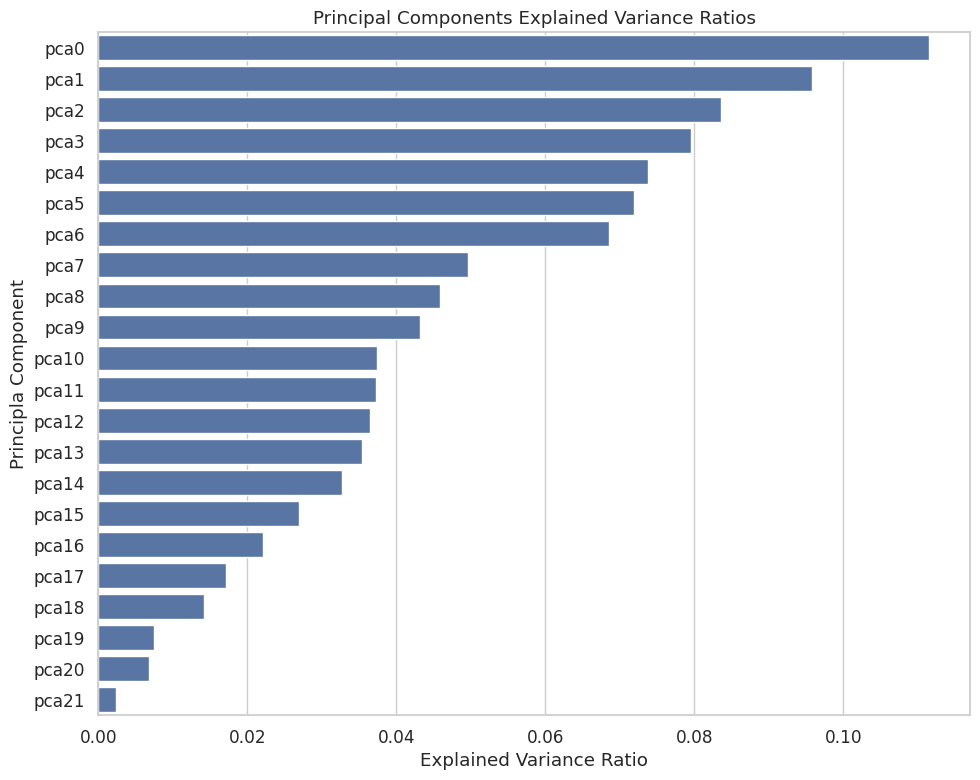

In [52]:
plt.figure(figsize=(10, 8))

ax = sns.barplot(
    y=pca.get_feature_names_out(),
    x=pca.explained_variance_ratio_
)
ax.set(
    title="Principal Components Explained Variance Ratios",
    ylabel="Principla Component",
    xlabel="Explained Variance Ratio"
)
plt.tight_layout()

In [53]:
# select the number of features that represent %95 of the explained variance ratio
explained_var_ratio_095 = pd.DataFrame(
    data=np.cumsum(pca.explained_variance_ratio_)
).apply(lambda x: x <= 0.95)

X_train_pca_095 = X_train_pca[
    :, range(explained_var_ratio_095.sum().values[0])
]
X_test_pca_095 = X_test_pca[
    :, range(explained_var_ratio_095.sum().values[0])
]

In [54]:
components_loadings = pd.DataFrame(
    data=abs(pca.components_.T),
    columns=pca.get_feature_names_out(),
    index=features_encoded.columns
)

print("components loading:")
print("two most important features in each component highlighted.")
components_loadings.style.highlight_quantile(props="background-color: green; color: black", axis=0, q_left=0.95)

components loading:
two most important features in each component highlighted.


,pca0,pca1,pca2,pca3,pca4,pca5,pca6,pca7,pca8,pca9,pca10,pca11,pca12,pca13,pca14,pca15,pca16,pca17,pca18,pca19,pca20,pca21
Major_Category_humanities,0.175285,0.118755,0.091758,0.417640,0.318358,0.075937,0.010055,0.008725,0.001534,0.019136,0.506367,0.278457,0.041805,0.316784,0.135853,0.014123,0.018660,0.017853,0.039739,0.053999,0.452551,0.000046
Major_Category_medical,0.055139,0.039365,0.032161,0.033097,0.243067,0.516824,0.232162,0.039911,0.020551,0.015411,0.485597,0.427376,0.059755,0.054967,0.098011,0.019480,0.011896,0.018948,0.031741,0.058230,0.413528,0.001981
Major_Category_business,0.052016,0.169894,0.347888,0.442536,0.133201,0.119244,0.055027,0.002132,0.024849,0.015029,0.062220,0.449193,0.301038,0.138854,0.119733,0.010544,0.003112,0.023015,0.027609,0.079716,0.527327,0.000955
Major_Category_stem,0.276385,0.311995,0.260959,0.019228,0.256942,0.201069,0.107508,0.036798,0.040455,0.010607,0.076859,0.068858,0.298115,0.377897,0.260566,0.026529,0.013947,0.029835,0.010970,0.078753,0.564229,0.002176
Year_of_Study,0.027092,0.057219,0.031861,0.020050,0.066604,0.009443,0.008617,0.847773,0.173097,0.072573,0.077847,0.010981,0.099147,0.293951,0.186749,0.299967,0.053201,0.030524,0.031653,0.005775,0.001455,0.062871
Pre_Semester_GPA,0.112107,0.434345,0.480219,0.215295,0.014210,0.018989,0.000229,0.107422,0.146678,0.009557,0.011357,0.008992,0.013491,0.013879,0.015497,0.069326,0.012545,0.005085,0.022515,0.093333,0.016143,0.687614
Weekly_GenAI_Hours,0.510096,0.023121,0.160162,0.095949,0.112267,0.011459,0.116774,0.044655,0.049226,0.035141,0.053524,0.052576,0.161506,0.157400,0.021600,0.206964,0.068099,0.061529,0.749940,0.015161,0.038625,0.006476
Primary_Use_Case_copywriting/drafting,0.139087,0.128286,0.104813,0.436877,0.375600,0.106550,0.012084,0.020557,0.028403,0.023208,0.452467,0.233324,0.038699,0.221033,0.154146,0.009968,0.003480,0.017703,0.010815,0.519812,0.000890,0.063100
Primary_Use_Case_ideation,0.034940,0.138458,0.321323,0.435844,0.151821,0.138581,0.069162,0.008139,0.011290,0.018532,0.090492,0.500727,0.323489,0.115352,0.125555,0.009854,0.009858,0.023341,0.000417,0.482845,0.092613,0.061140
Primary_Use_Case_summarizing_reading,0.031735,0.040054,0.044613,0.029047,0.241924,0.548398,0.236417,0.006789,0.012872,0.020525,0.463786,0.365639,0.046813,0.021810,0.113230,0.001689,0.007083,0.026607,0.006300,0.452791,0.076091,0.053605


In [55]:
print(f"number of the original dataset features: {X_train.shape[1]}")
print(f"number of the selected principal components: {X_train_pca_095.shape[1]}")

number of the original dataset features: 22
number of the selected principal components: 16


we can see that in the first two principal components the most important features that has the most effect on the creation these principal components are: Weekly_GenAI_Hours, Perceived_AI_Dependency, Pre_Semester_GPA, Post_Semester_GPA.

We reduced the number of the selected features using PCA from 22 to 16. 16 features that represent the data without significantly loss of information and they preserve more than %95 of the explained variance ration in the data.

In [56]:
# reconstruction error for PCA transformation
reconstruction_error_pca_mse = mean_squared_error(y_true=X_test_scaled, y_pred=pca.inverse_transform(X_test_pca))
print(f"Reconstruction Error of the PCA Transformation: {reconstruction_error_pca_mse} -> zero")

Reconstruction Error of the PCA Transformation: 1.8968112886241906e-30 -> zero


### Model Selection and Training:

In [57]:
# training the model using principal components
linreg_pca = LinearRegression()
linreg_pca.fit(X_train_pca_095, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](16,)","[-0.01, 0.03,-0.01,..., 0. ,-0.03,-0.01]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.2026
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,16
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,16
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](16,)","[313.24,290.47,271.26,...,176.41,169.64,153.89]"


In [58]:
# training model using original scaled features
linreg_org = LinearRegression()
linreg_org.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](22,)","[-0. , 0. ,-0. ,..., 0.5, 0. , 0. ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.2026
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,22
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,22
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](22,)","[313.24,290.47,271.26,..., 81.07, 77.44, 46.3 ]"


In [72]:
from metrics import adjusted_r2_score

# evaluating models:
# model trained on principal components
y_pred_pca = linreg_pca.predict(X_test_pca_095)

mse_pca = mean_squared_error(y_true=y_test, y_pred=y_pred_pca)
rmse_pca = root_mean_squared_error(y_true=y_test, y_pred=y_pred_pca)
mae_pca = mean_absolute_error(y_true=y_test, y_pred=y_pred_pca)
r2_score_pca = r2_score(y_true=y_test, y_pred=y_pred_pca)
adjusted_r2_score_pca = adjusted_r2_score(r2_score_pca, y_test.shape[0], X_test.shape[1])

# model trained on original features scaled
y_pred_org = linreg_org.predict(X_test_scaled)

mse_org = mean_squared_error(y_true=y_test, y_pred=y_pred_org)
rmse_org = root_mean_squared_error(y_true=y_test, y_pred=y_pred_org)
mae_org = mean_absolute_error(y_true=y_test, y_pred=y_pred_org)
r2_score_org = r2_score(y_true=y_test, y_pred=y_pred_org)
adjusted_r2_score_org = adjusted_r2_score(r2_score_org, y_test.shape[0], X_test.shape[1])


metrics_df = pd.DataFrame(
    {
        "pca": [mse_pca, rmse_pca, mae_pca, adjusted_r2_score_pca],
        "org": [mse_org, rmse_org, mae_org, adjusted_r2_score_org]
	},
    index=["MSE", "RMSE", "MAE", "Adjusted R-Squared"]
)
metrics_df

,pca,org
MSE,0.025544,6.921610e-31
RMSE,0.159826,8.319622e-16
MAE,0.125312,6.702319e-16
Adjusted R-Squared,0.255047,1.000000e+00


In [70]:
# final model evaluation
linreg = LinearRegression()
pipe = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("regressor", LinearRegression())
	]
)

# generating scorers for cv scoring
mse_scorer = make_scorer(score_func=mean_squared_error)
rmse_scorer = make_scorer(score_func=root_mean_squared_error)
mae_scorer = make_scorer(score_func=mean_absolute_error)
r2_score_scorer = make_scorer(score_func=r2_score)

# generating stable evalution metrics
mse_cv = cross_val_score(
    estimator=pipe, X=X, y=y,
    scoring=mse_scorer, cv=5, n_jobs=-1
)
rmse_cv = cross_val_score(
    estimator=pipe, X=X, y=y,
    scoring=rmse_scorer, cv=5, n_jobs=-1
)
mae_cv = cross_val_score(
    estimator=pipe, X=X, y=y,
    scoring=mae_scorer, cv=5, n_jobs=-1
)
r2_score_cv = cross_val_score(
    estimator=pipe, X=X, y=y,
    scoring=r2_score_scorer, cv=5, n_jobs=-1
)
adjusted_r2_score_cv = adjusted_r2_score(r2_score_cv, n_samples=40_000, n_features=X_train.shape[1])

In [73]:
metrics_df = pd.concat(
    [
        metrics_df,
        pd.DataFrame(
            data={"cv": [mse_cv.mean(), rmse_cv.mean(), mae_cv.mean(), adjusted_r2_score_cv.mean()]},
            index=["MSE", "RMSE", "MAE", "Adjusted R-Squared"]
		)
	],
    axis=1
)

print("Metrics Data Frame:")
metrics_df

Metrics Data Frame:


,pca,org,cv
MSE,0.025544,6.921610e-31,5.702364e-31
RMSE,0.159826,8.319622e-16,7.355006e-16
MAE,0.125312,6.702319e-16,5.830786e-16
Adjusted R-Squared,0.255047,1.000000e+00,1.000000e+00


In [88]:
# calculating the training and test scores
mse_org_on_train_data = mean_squared_error(y_true=y_train, y_pred=linreg_org.predict(X_train_scaled))
rmse_org_on_train_data = root_mean_squared_error(y_true=y_train, y_pred=linreg_org.predict(X_train_scaled))
mae_org_on_train_data = mean_absolute_error(y_true=y_train, y_pred=linreg_org.predict(X_train_scaled))
r2_score_org_on_train_data = r2_score(y_true=y_train, y_pred=linreg_org.predict(X_train_scaled))
adjusted_r2_score_org_on_train_data = adjusted_r2_score(r2_score_org_on_train_data, y_train.shape[0], X_train.shape[1])

mse_diff = mse_org - mse_org_on_train_data
rmse_diff = rmse_org - rmse_org_on_train_data
mae_diff = mae_org - mae_org_on_train_data
adjusted_r2_score_diff = adjusted_r2_score_org - adjusted_r2_score_org_on_train_data

print("Difference Scores between train and test data:")
print(f"MSE: {mse_diff}")
print(f"RMSE: {rmse_diff}")
print(f"MAE: {mae_diff}")
print(f"Adjusted R-Squared: {adjusted_r2_score_diff}")

Difference Scores between train and test data:
MSE: -3.967064203222871e-33
RMSE: -2.380755062076957e-18
MAE: -5.443562267615476e-19
Adjusted R-Squared: 0.0


There is no sign of overfitting and we have a good fit.

In [81]:
train_sizes, train_score, test_score = learning_curve(
    estimator=pipe,
    X=X,
    y=y,
    train_sizes=np.linspace(0.1, 1, 10) ,
    cv= 5,
    scoring=mse_scorer,
    n_jobs=-1,
    random_state=42
)

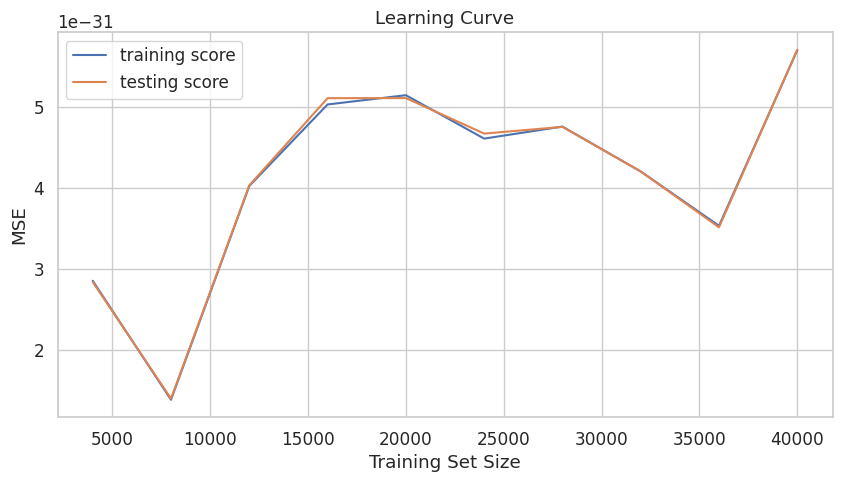

In [92]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(train_sizes, train_score.mean(axis=1), label="training score")
ax.plot(train_sizes, test_score.mean(axis=1), label="testing score")
ax.set(
    title="Learning Curve",
    ylabel="MSE",
    xlabel="Training Set Size"
)
ax.legend()

By looking at the evaluation metrics and learing curve we got that:
- Based-on the learning curve and the very small difference between training and testing scores we can say that our model doesn't overfit to the training data.
- Adjusted R-Squared metric is equal to 1 so we have a very good fit and we can predict about %100 percent of the variations in the dependent variable using independent variables.
- As the MSE is not high and RMSE and MAE have no meaningful difference with each other we can say there is no meaningful and impactful outlier in our data.

This project works very good. I have an idea to make this regression task a classification task to find that what is the GPA difference based-on the features between these categories: ["low", "medium", "high"]. 

I think using these trick we can gain valuable knowledges from this data (although it won't be as accurate as this project and we can't get exact numerical GPA difference from the model but maybe using less features we can train a great model). It could be a great training on classification as well.